# Plot polar maps of boreal domain data - Circmpolar Height and AGB maps
Paul Montesano, PhD   
Oct 2024  
* run this notebook R kernel on workspace `r_v3.1.5`

In [1]:
#system("conda activate r-with-gdal")

In [89]:
library(aws.s3)
#library(rgdal)
library(raster)
library(tidyverse)
library(dplyr)
library(grid)
library(gridExtra)
library(RColorBrewer)
library(data.table)

library(fs)
library(sf)
#library(rgdal)

library(rgeos)
library(mapproj)
#library(rgee)
library(viridis)
#library(wesanderson)
library(scales)
library(tools)
library(patchwork)

library(rnaturalearth)
library(rnaturalearthdata)
#library(feather)

#conda install -c conda-forge r-rnaturalearth r-rnaturalearthdata r-mapproj r-rgeos r-viridis r-wesanderson r-patchwork r-aws.s3 r-feather r-rockchalk

# Paths

In [90]:
boreal_shp_fn = '/projects/shared-buckets/montesano/databank/arc/wwf_circumboreal_Dissolve.gpkg'
#boreal_shp_fn = '/projects/shared-buckets/montesano/databank/arc/boreal.shp'

## Set output figure dir.

In [100]:
MAINDIR = '/projects/my-public-bucket/boreal_HLS_ATL08_metadata'
OUT_FIGURE_DIR = paste0(MAINDIR, '/paper_figs')
OUT_DATA_DIR = paste0(MAINDIR, '/data')

### Mapping functions and vars

In [92]:
source('/projects/code/3dsi/boreal_map_functions.R') 

[1] "MAAP"
[1] "MAAP"


#### Note: the ability to make these maps is changing...

The use of type 'SpatialPolygons' will go away.  
This means 'crop' will need to be changed to crop an 'sf' object.

But the whole polar mapping function is built around the use of 'SP', not 'sf'.-  

THis will need work and testing to be able to reproduce these polar maps.

At the moment, these still works in `r-env-3.6.3` on Prism

In [4]:
# Circ map new: trying to combine the best of the sf and sp approaches
DO_MAP_BOREAL_SP <- function( MAP_EXTENT = extent(-180,180,45,90), xlim=NULL, ylim=NULL, rotate_map=0, proj_name = 'azequalarea', LAYER_LIST=NULL, 
                             BOREAL_SHP_FN = '/projects/my-public-bucket/misc_files/Ecoregions2017_boreal_m.shp'){
  #
  # Map with a polar projection
  #
  
  # Color scale help
  #https://biostats.w.uib.no/color-scale-for-continuous-variables/
  
  #source(path("C:\\Users\\pmontesa\\Google Drive\\Work\\R","plot_functions.R"))
  # Shapefiles
  
  
  #world <- crop(ne_countries(scale = "medium", returnclass = "sp"), MAP_EXTENT)
  world <- raster::crop(as(ne_countries(scale = "medium", returnclass = "sf"), 'Spatial'), MAP_EXTENT)
  #world = st_crop(x = ne_countries(scale = "medium", returnclass = "sf") %>% st_make_valid() ,  y = ext)
  
  # WWF
  #boreal <- shp_fort_join("D:\\databank\\wwf\\arc\\wwf_circumboreal_Dissolve.shp", MAP_EXTENT, REPROJECT = TRUE)
  # TerraPulse
  boreal <- shp_fort_join(boreal_shp_fn, MAP_EXTENT, REPROJECT = TRUE)
  
  map_list_base = list(
    
    geom_polygon(data = fortify(world), aes(x = long, y = lat, group = group), fill="grey90", color=NA),
    geom_polygon(data = boreal, aes(x = long, y = lat, group = group), color=NA, fill="grey70"))
    
  map_list_top = list(
    
    geom_polygon(data = fortify(world), aes(x = long, y = lat, group = group), fill=NA, color="black", size=0.1 ),
    
    theme_minimal() , 
    theme(axis.text = element_blank(), axis.title = element_blank() ) ,
    
    #geom_polygon(data = fortify(continents.df_stereo), aes(x = long, y = lat, group = group), fill = NULL, colour = "black", size=0.25) +
    #scale_color_distiller(palette = "Greens", direction = 1, name = "%"),
    #scale_color_manual(values = COLOR_PAL, name = map_str) ,
    guides(guide = guide_legend(direction = "horizontal", nrow=1, label.position = "bottom", title.position = "bottom") ) ,
    theme(legend.position="top",
          legend.title = element_text(size=9),
          #       legend.direction  = 'vertical',
          legend.key.width  = unit(1.0, "cm"),
          legend.key.height = unit(.25, "cm")  )
  )
  
  if(is.null(LAYER_LIST)){
    map_list = list(
      map_list_base,
      map_list_top
    )
  }else{
    map_list = list(
      map_list_base,
      LAYER_LIST,
      map_list_top
    )
  }
  
  p_map = ggplot() + map_list +
    #coord_map_stereo_list(proj_name = proj_name, min_lat = MAP_EXTENT[3], rotation=rotate_map, xlim = xlim, ylim = ylim)
    coord_map_stereo_list(proj_name = proj_name, min_lat = MAP_EXTENT[3], rotation=rotate_map)
  
  if(FALSE){
    out_plot_fn = paste0("D:/projects/3dsi/plots/map_boreal_",proj_name,"_", format(Sys.time(), "_%Y%m%d"),'.png')
    print(out_plot_fn)
    ggsave(plot = p_map ,
           file = out_plot_fn,
           device = 'png', dpi = 300, width = 5, height = 5)
  }
  #print(p_map)
  return(p_map)
  
}

coord_map_stereo_list <- function(proj_name = "stereo", rotation = 0, min_lat = 50, xlims=NULL, ylims=NULL, LABEL_SIZE=3){ 
  
  # Defines the x axes required
  lat_lines = seq(min_lat+10, 80, by = 10)
  lat_labs = paste0(seq(min_lat+10, 80, by = 10), "\u00B0N")
  
  lon_lines = seq(0, 330, by = 30)
  lon_labs = c("0", paste0(seq(30, 150, by = 30), "°E"), "180", rev(paste0(seq(30, 150, by = 30), "°W")))
  
  
  return(list(
    # Convert to polar coordinates
    coord_map(proj_name, orientation = c(90, 0, rotation, xlims=xlims, ylims=ylims)), #"ortho""
    scale_y_continuous(breaks = seq(45, 90, by = 5), labels = NULL),
    
    # Removes Axes and labels
    scale_x_continuous(breaks = NULL),
    xlab(""),
    ylab(""),
    
    # Adds axes
    # Latitude
    geom_hline(aes(yintercept = lat_lines), size = 0.25, color = "grey80", linetype = "dotted"),
    # Outer circular border
    geom_hline(aes(yintercept = min_lat), size = 0.25), #1
    # Longitude
    geom_vline(aes(xintercept = lon_lines), size = 0.25, color = "grey80", linetype = "dotted"),
    #geom_segment(aes(y = 45, yend = 85, x = x_lines, xend = x_lines), linetype = "dotted") +
    
    # Adds labels
    #geom_text(aes(x = 0, y = lat_lines, hjust = 0.5, label = lat_labs)),
    geom_label(aes(x = 0, y = lat_lines, label = lat_labs), label.size = NA, size=LABEL_SIZE, color = "black", fill="white", label.padding=unit(0.1,"lines")),
    #geom_text(aes(x = lon_lines, y = min_lat-3, hjust = 0.5, vjust = 0.5, label = lon_labs), size = 2.5), #hjust = 0.5
    # min-3 so lon labels are centered over outer line
    geom_label(aes(x = lon_lines, y = min_lat-3, label = lon_labs), label.size = NA,  hjust='inward', vjust='inward', size = LABEL_SIZE, color = "black", fill="white", label.padding=unit(0.1,"lines")),  #y = min_lat-3 why used to be this?
    
    ##guides(fill=FALSE)+
    
    # Change theme to remove axes and ticks
    theme(panel.background = element_blank(),
          #panel.grid = element_line(size = 0.25, linetype = 'dotted', colour = "grey50"),
          axis.ticks=element_blank())
    #,
    #labs(caption = "Source: circ_tte_map.Rmd")
  ))
}  

gridCreate<-function(shp, res,proj_out, buffer=10000){
  
  if (!is.null(buffer)){
    shp<-buffer(shp, width=buffer)
  }
  ext <- floor(extent(shp))
  rr <- raster(ext, res=res)
  rr <- rasterize(shp, rr, field=1)
  rr[!is.na(rr[])]<-1:length(rr[!is.na(rr[])])
  grid<-rasterToPolygons(rr)
  crs(grid)<-projection(shp)
  if (!proj_out==projection(shp)){
    grid<-spTransform(grid,CRS(proj_out))
  }
  return(grid)  
}

In [93]:
crs_canalb = "+proj=aea +lat_0=40 +lon_0=180 +lat_1=50 +lat_2=70 +x_0=0 +y_0=0 +datum=NAD83 +units=m +no_defs"
crs_albers = "+proj=aea +lat_1=50 +lat_2=70 +lat_0=40 +lon_0=180 +x_0=0 +y_0=0 +ellps=GRS80 +datum=NAD83 +units=m +no_defs"
crs_gcs = "+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs"

### Get Boreal EXTENT

#### Read boreal extent, read tiles, then clip tiles to boreal extent

In [94]:
boreal_shp_fn = '/projects/shared-buckets/nathanmthomas/analyze_agb/input_zones/wwf_circumboreal_Dissolve.geojson'
boreal = st_read(boreal_shp_fn)
boreal_albers<-spTransform(sf:::as_Spatial(boreal),CRS(crs_albers))

Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/shared-buckets/nathanmthomas/analyze_agb/input_zones/wwf_circumboreal_Dissolve.geojson' 
  using driver `GeoJSON'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -164.95 ymin: 44.39544 xmax: 169.9216 ymax: 71.41746
Geodetic CRS:  WGS 84


#### Get all tiles delivered to DAAC for this project

In [96]:
boreal_tile_DAAC_path = '/projects/shared-buckets/montesano/databank/daac/boreal_tiles_v004_AGB_H30_2020_ORNLDAAC.gpkg'
boreal_tiles_DAAC = st_read(boreal_tile_DAAC_path)
boreal_tile_num_DAAC_list =  boreal_tiles_DAAC %>% as.data.frame() %>% dplyr::select(tile_num) %>% as.list()
boreal_tile_num_DAAC_list = unlist(boreal_tile_num_DAAC_list[[1]])
length(boreal_tile_num_DAAC_list)

Reading layer `boreal_tiles_v004_AGB_H30_2020_ORNLDAAC' from data source 
  `/projects/shared-buckets/montesano/databank/daac/boreal_tiles_v004_AGB_H30_2020_ORNLDAAC.gpkg' 
  using driver `GPKG'
Simple feature collection with 3907 features and 2 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -180 ymin: 43.75195 xmax: 180 ymax: 78.53133
Geodetic CRS:  WGS 84


[1] 3907

In [108]:
boreal_tiles_gcs_ATL08obs = st_read(paste0(OUT_DATA_DIR, '/boreal_tiles_v004_ATL08_filt_smry_nobs.gpkg')) %>% 
                                st_transform(4326) %>% 
                                dplyr::filter(tile_num %in% boreal_tile_num_DAAC_list)

Reading layer `boreal_tiles_v004_ATL08_filt_smry_nobs' from data source 
  `/projects/my-public-bucket/boreal_HLS_ATL08_metadata/data/boreal_tiles_v004_ATL08_filt_smry_nobs.gpkg' 
  using driver `GPKG'
Simple feature collection with 4956 features and 8 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -6111478 ymin: 1233304 xmax: 6308522 ymax: 10323300
Projected CRS: unnamed


In [112]:
str(boreal_tiles_gcs_ATL08obs)

Classes ‘sf’ and 'data.frame':	3907 obs. of  9 variables:
 $ tile_num            : num  4 9 10 11 12 13 16 17 18 19 ...
 $ n_obs.atl08v005     : num  226 2637 1 2727 3133 ...
 $ n_obs.atl08v006_2019: num  96 1083 0 6067 195 ...
 $ n_obs.atl08v006_2020: num  0 1206 0 7748 2300 ...
 $ n_obs.atl08v006_2021: num  0 559 0 7602 3790 ...
 $ n_obs.atl08v006_2022: num  491 1367 0 3371 172 ...
 $ n_obs.atl08v006_2023: num  0 1641 0 5013 5346 ...
 $ n_obs.atl08v006_2024: num  0 740 265 8340 242 ...
 $ geom                :sfc_POLYGON of length 3907; first list element: List of 1
  ..$ : num [1:5, 1:2] 7.92 6.67 7.48 8.75 7.92 ...
  ..- attr(*, "class")= chr [1:3] "XY" "POLYGON" "sfg"
 - attr(*, "sf_column")= chr "geom"
 - attr(*, "agr")= Factor w/ 3 levels "constant","aggregate",..: NA NA NA NA NA NA NA NA
  ..- attr(*, "names")= chr [1:8] "tile_num" "n_obs.atl08v005" "n_obs.atl08v006_2019" "n_obs.atl08v006_2020" ...


### Sum # of ATL08 30 m obs per `year` for a set of tiles

In [116]:
smry_year_ATL08_obs = boreal_tiles_gcs_ATL08obs %>% 
    as.data.frame() %>% drop_na() %>%
    summarize(
        'c2020' = sum(n_obs.atl08v005),
        '2019' = sum(n_obs.atl08v006_2019),
        '2020' = sum(n_obs.atl08v006_2020),
        '2021' = sum(n_obs.atl08v006_2021),
        '2022' = sum(n_obs.atl08v006_2022),
        '2023' = sum(n_obs.atl08v006_2023),
        '2024' = sum(n_obs.atl08v006_2024)
        )
smry_year_ATL08_obs.m = melt(smry_year_ATL08_obs)

Warning message in melt(smry_year_ATL08_obs):
“The melt generic in data.table has been passed a data.frame and will attempt to redirect to the relevant reshape2 method; please note that reshape2 is deprecated, and this redirection is now deprecated as well. To continue using melt methods from reshape2 while both libraries are attached, e.g. melt.list, you can prepend the namespace like reshape2::melt(smry_year_ATL08_obs). In the next version, this warning will become an error.”
No id variables; using all as measure variables



In [118]:
smry_year_ATL08_obs.m['domain'] = 'DAAC'
smry_year_ATL08_obs.m['version'] = 'v6'
smry_year_ATL08_obs.m[smry_year_ATL08_obs.m$variable == 'c2020','version'] = 'v5'
smry_year_ATL08_obs.m['value_scaled'] = smry_year_ATL08_obs.m['value'] / 1e6
smry_year_ATL08_obs.m

variable,value,domain,version,value_scaled
<fct>,<dbl>,<chr>,<chr>,<dbl>
c2020,22409688,DAAC,v5,22.40969
2019,27718956,DAAC,v6,27.71896
2020,46376946,DAAC,v6,46.37695
2021,26873959,DAAC,v6,26.87396
2022,44908981,DAAC,v6,44.90898
2023,26959922,DAAC,v6,26.95992
2024,30332797,DAAC,v6,30.33280


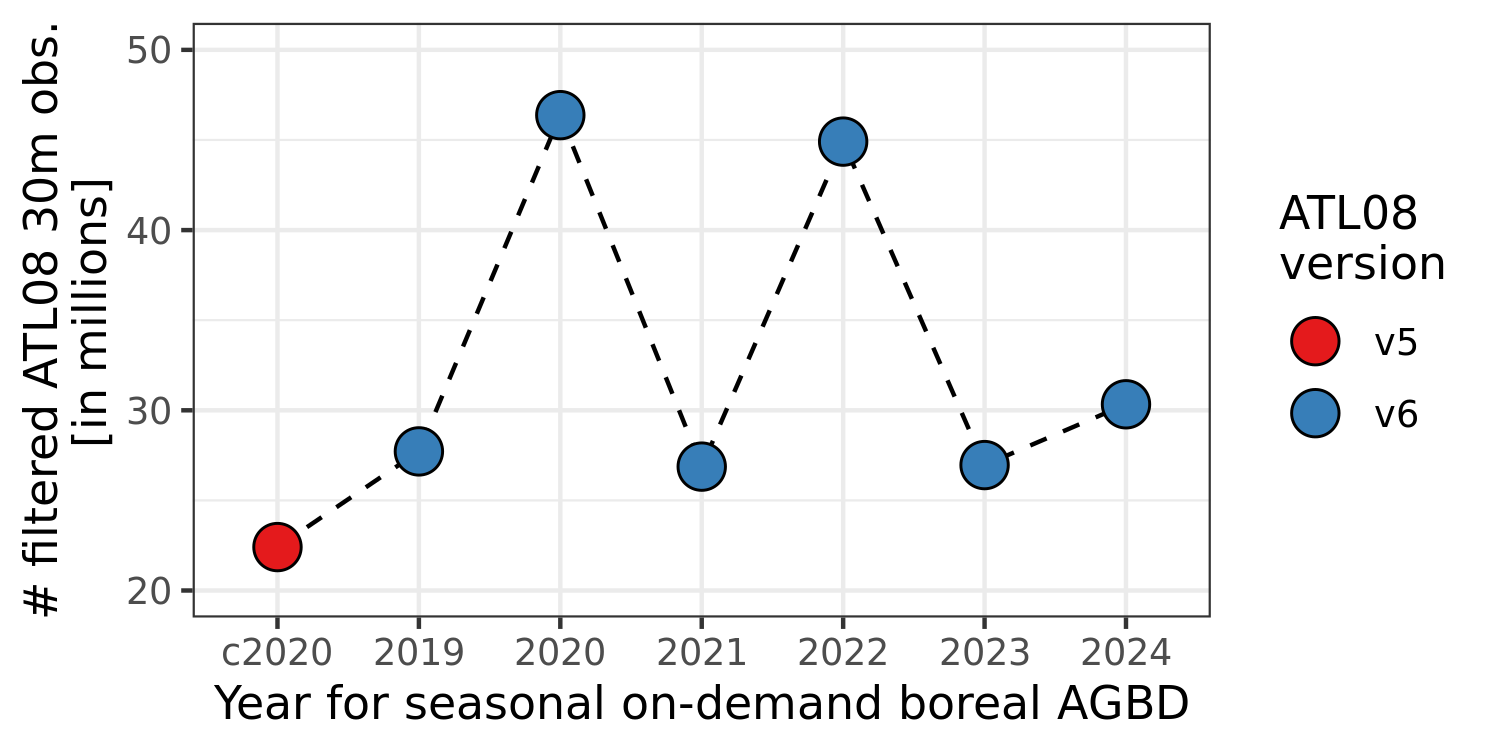

In [119]:
options(repr.plot.width = 5, repr.plot.height = 2.5, repr.plot.res = 300)

ggplot(smry_year_ATL08_obs.m, aes(x=variable, y=value_scaled, group=domain, fill=version)) +
geom_line(linetype = 'dashed') +
geom_point(size=5, shape=21, color='black') +
scale_fill_brewer(palette=6, type='qual', name='ATL08\nversion') +
theme_bw() +
labs(y='# filtered ATL08 30m obs.\n [in millions]', x='Year for seasonal on-demand boreal AGBD') + scale_y_continuous(lim = c(20, 50))

In [13]:
boreal_tiles_gcs_ATL08obs_df = fortify_sf(boreal_tiles_gcs_ATL08obs)

Warning message:
“`fortify(<SpatialPolygonsDataFrame>)` was deprecated in ggplot2 3.4.4.
ℹ Please migrate to sf.”
Regions defined for each Polygons


In [14]:
# Melt for facet plotting
boreal_tiles_gcs_ATL08obs_df.m = melt(boreal_tiles_gcs_ATL08obs_df, id.vars = c('long','lat','order','hole','piece','id','group','tile_num','n_obs.atl08v005'),
                                      meas.vars = c('n_obs.atl08v006_2019','n_obs.atl08v006_2020','n_obs.atl08v006_2021','n_obs.atl08v006_2022','n_obs.atl08v006_2023') )

Warning message in melt(boreal_tiles_gcs_ATL08obs_df, id.vars = c("long", "lat", :
“The melt generic in data.table has been passed a data.frame and will attempt to redirect to the relevant reshape2 method; please note that reshape2 is deprecated, and this redirection is now deprecated as well. To continue using melt methods from reshape2 while both libraries are attached, e.g. melt.list, you can prepend the namespace like reshape2::melt(boreal_tiles_gcs_ATL08obs_df). In the next version, this warning will become an error.”


In [15]:
head(boreal_tiles_gcs_ATL08obs_df.m)

,long,lat,order,hole,piece,id,group,tile_num,n_obs.atl08v005,variable,value
,<dbl>,<dbl>,<int>,<lgl>,<fct>,<chr>,<fct>,<dbl>,<dbl>,<fct>,<dbl>
1,7.923729,56.48187,1,FALSE,1,1,1.1,4,226,n_obs.atl08v006_2019,96
2,6.672362,56.91323,2,FALSE,1,1,1.1,4,226,n_obs.atl08v006_2019,96
3,7.483985,57.58611,3,FALSE,1,1,1.1,4,226,n_obs.atl08v006_2019,96
4,8.748943,57.14697,4,FALSE,1,1,1.1,4,226,n_obs.atl08v006_2019,96
5,7.923729,56.48187,5,FALSE,1,1,1.1,4,226,n_obs.atl08v006_2019,96
6,9.982641,56.69527,1,FALSE,1,2,2.1,9,2637,n_obs.atl08v006_2019,1083


### Maps of ATL08 obs for each year

In [16]:
map_theme = list(
    theme(legend.text=element_text(size=rel(0.35))),
    guides(fill=guide_colourbar(title="# of filtered ATL08 30m obs.", title.position = "top", label.position = "bottom"
                               # , keywidth = unit(4, "cm"), keyheight = unit(.25, "cm")
                               )
           ),
    scale_fill_viridis(option = 'turbo' 
                       , breaks=c(0,20000,40000)
                       , limits = c(0, 45000)
                       , labels=comma
                      #, trans='log'
                      )
    )

In [17]:
options(repr.plot.width = 6, repr.plot.height = 6, repr.plot.res = 300)

map_list = list()

for(i in seq_along(levels(factor(boreal_tiles_gcs_ATL08obs_df.m$variable))) ){
    
    VAR = levels(factor(boreal_tiles_gcs_ATL08obs_df.m$variable))[i]
    YEAR = unlist(strsplit(VAR, "_"))[3]
    
    ATL08obs_LAYER_LIST = list(
                            geom_polygon(data = boreal_tiles_gcs_ATL08obs_df.m %>% 
                                         filter(variable == VAR) %>% 
                                         drop_na(), 
                                                    aes(x = long, y = lat, group = group, fill=value), size=0.1)
                            , map_theme
                            , labs(title=YEAR, subtitle = paste0('n = ', scales::label_comma(accuracy = 1)(smry_year_ATL08_obs[,YEAR])) )
                            )
    map_list[[VAR]] = DO_MAP_BOREAL_SP(MAP_EXTENT=extent(-180,180,45,90), BOREAL_SHP_FN = wwf_circ_dis_fn, LAYER_LIST = ATL08obs_LAYER_LIST)
}

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


[1] "Using sf and coercing to Spatial object..."
Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers


Regions defined for each Polygons
Regions defined for each Polygons
Regions defined for each Polygons


[1] "Using sf and coercing to Spatial object..."
Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers


Regions defined for each Polygons
Regions defined for each Polygons
Regions defined for each Polygons


...

Regions defined for each Polygons
Regions defined for each Polygons
Regions defined for each Polygons


[1] "Using sf and coercing to Spatial object..."
Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers


Regions defined for each Polygons
Regions defined for each Polygons
Regions defined for each Polygons


[1] "Using sf and coercing to Spatial object..."
Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers


Regions defined for each Polygons
Regions defined for each Polygons
Regions defined for each Polygons


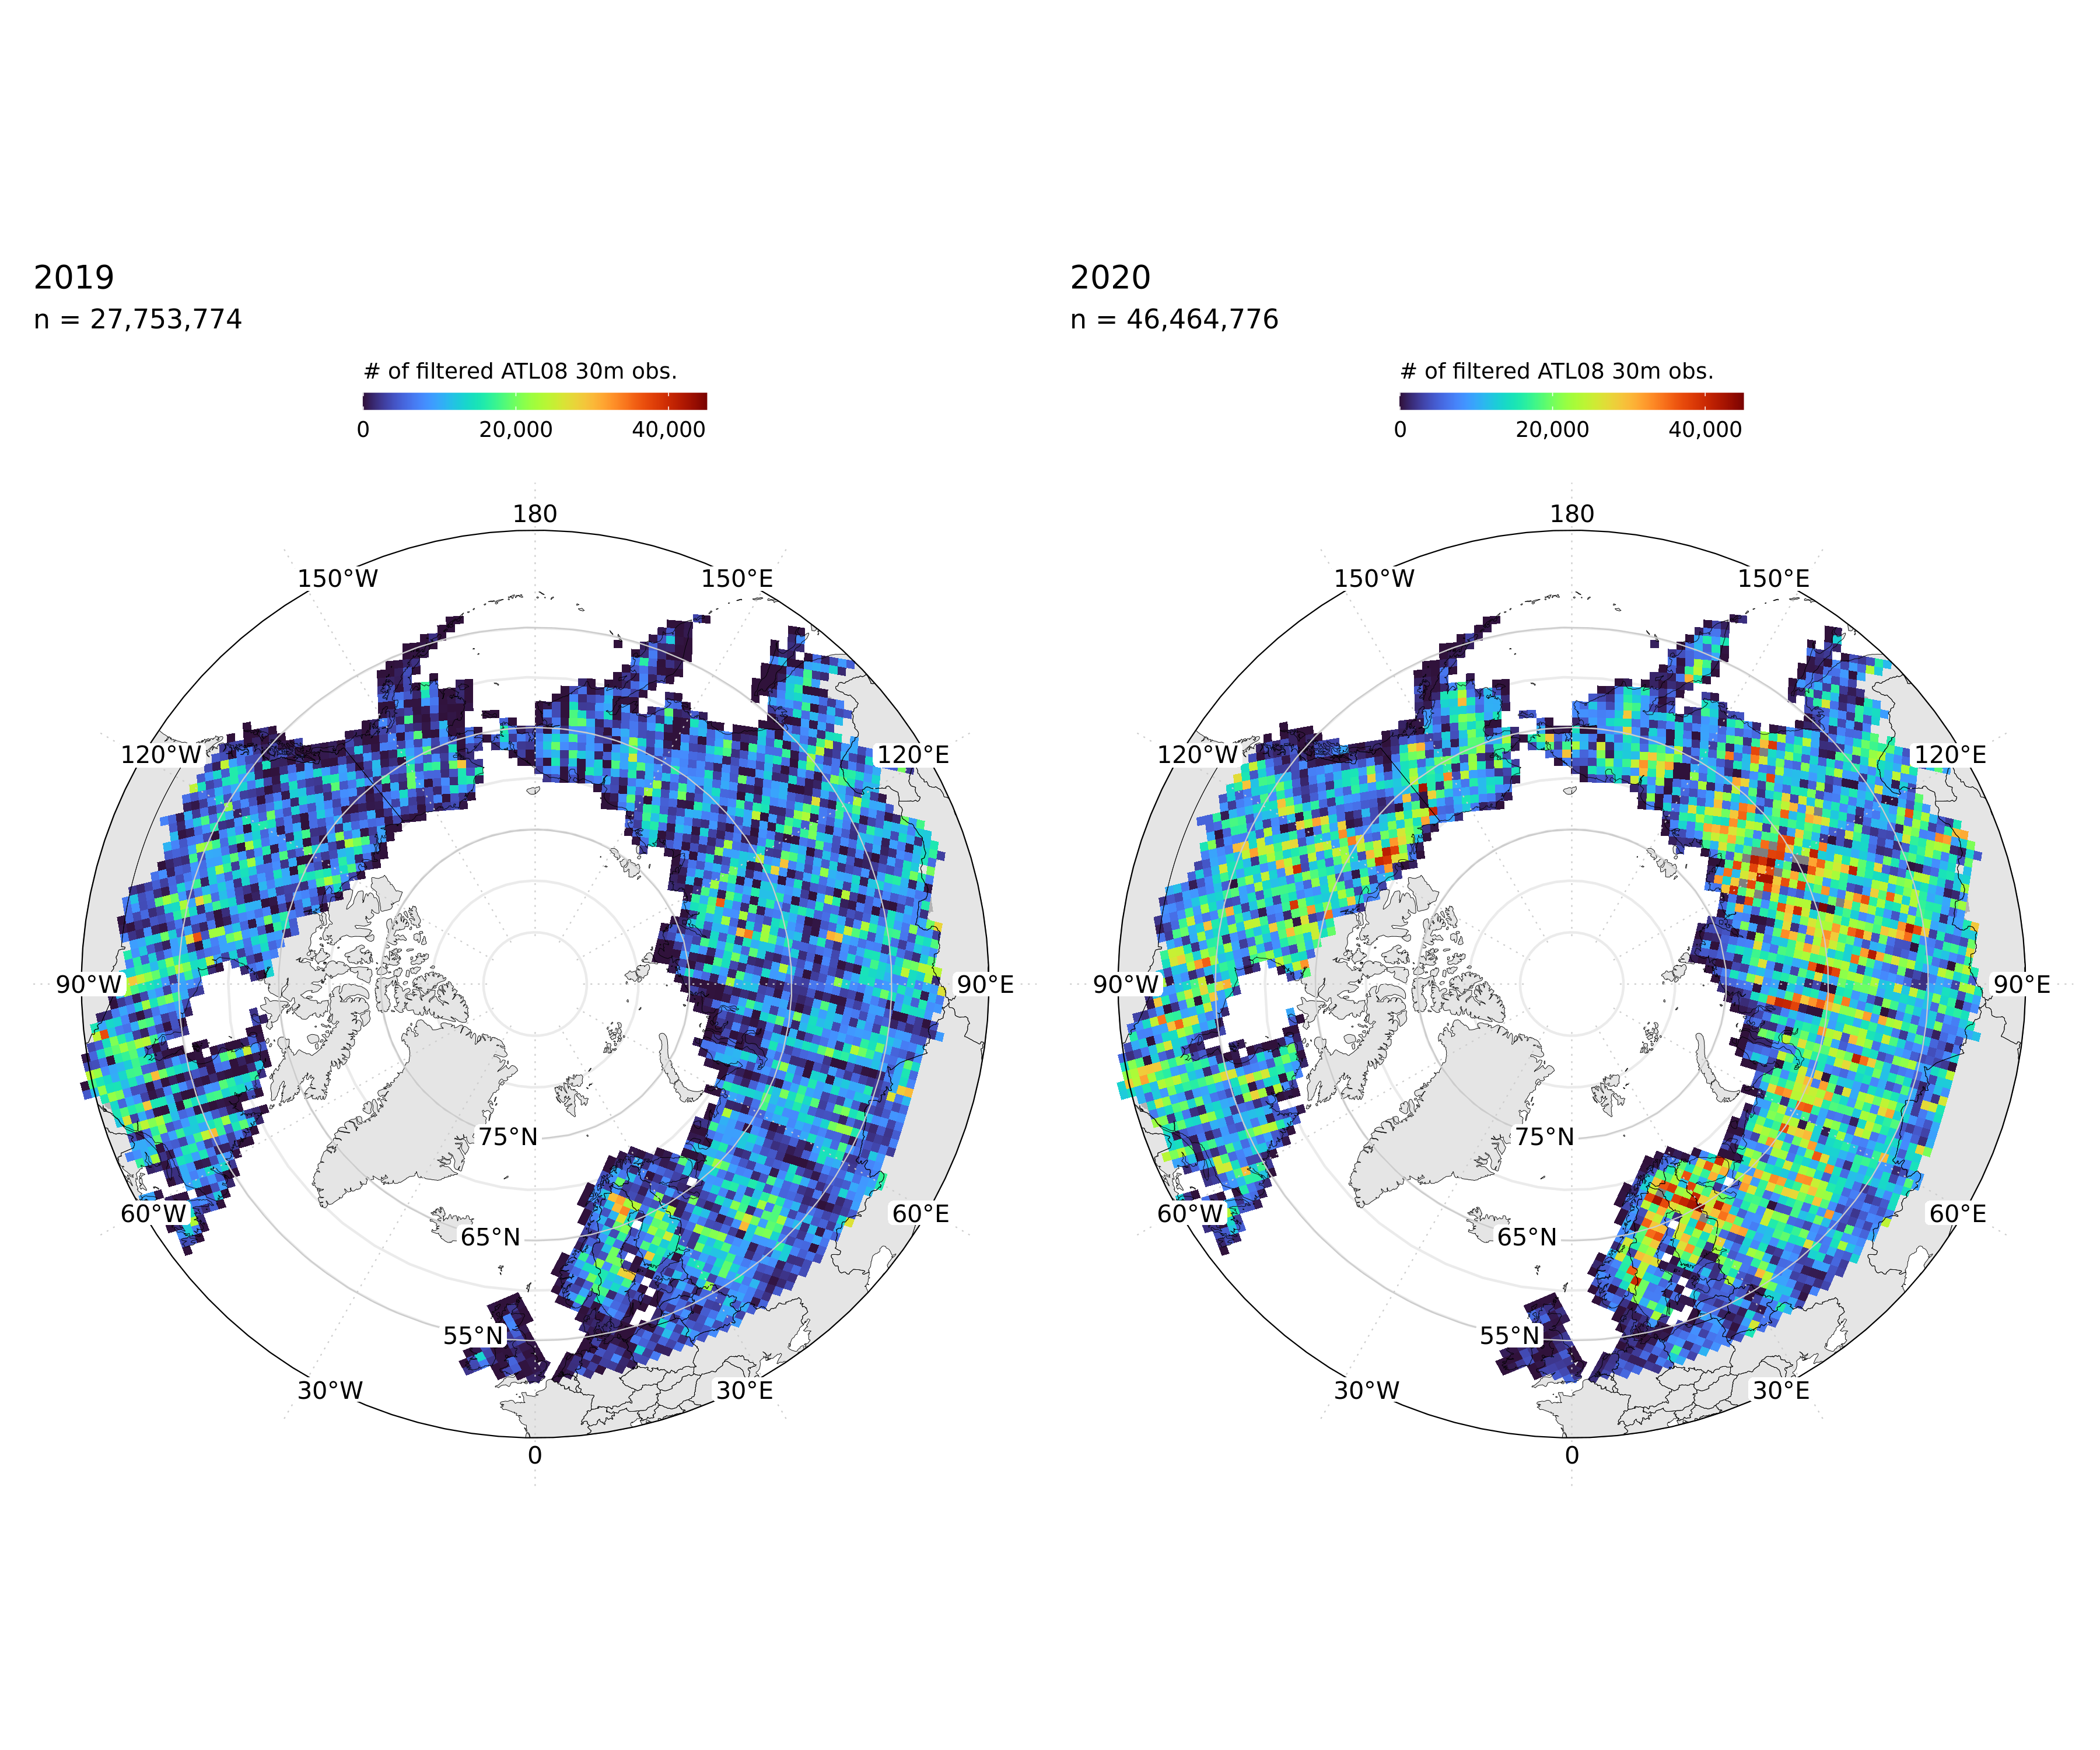

In [18]:
options(repr.plot.width = 12, repr.plot.height = 10, repr.plot.res = 300)

map_list[['n_obs.atl08v006_2019']] | map_list[['n_obs.atl08v006_2020']]

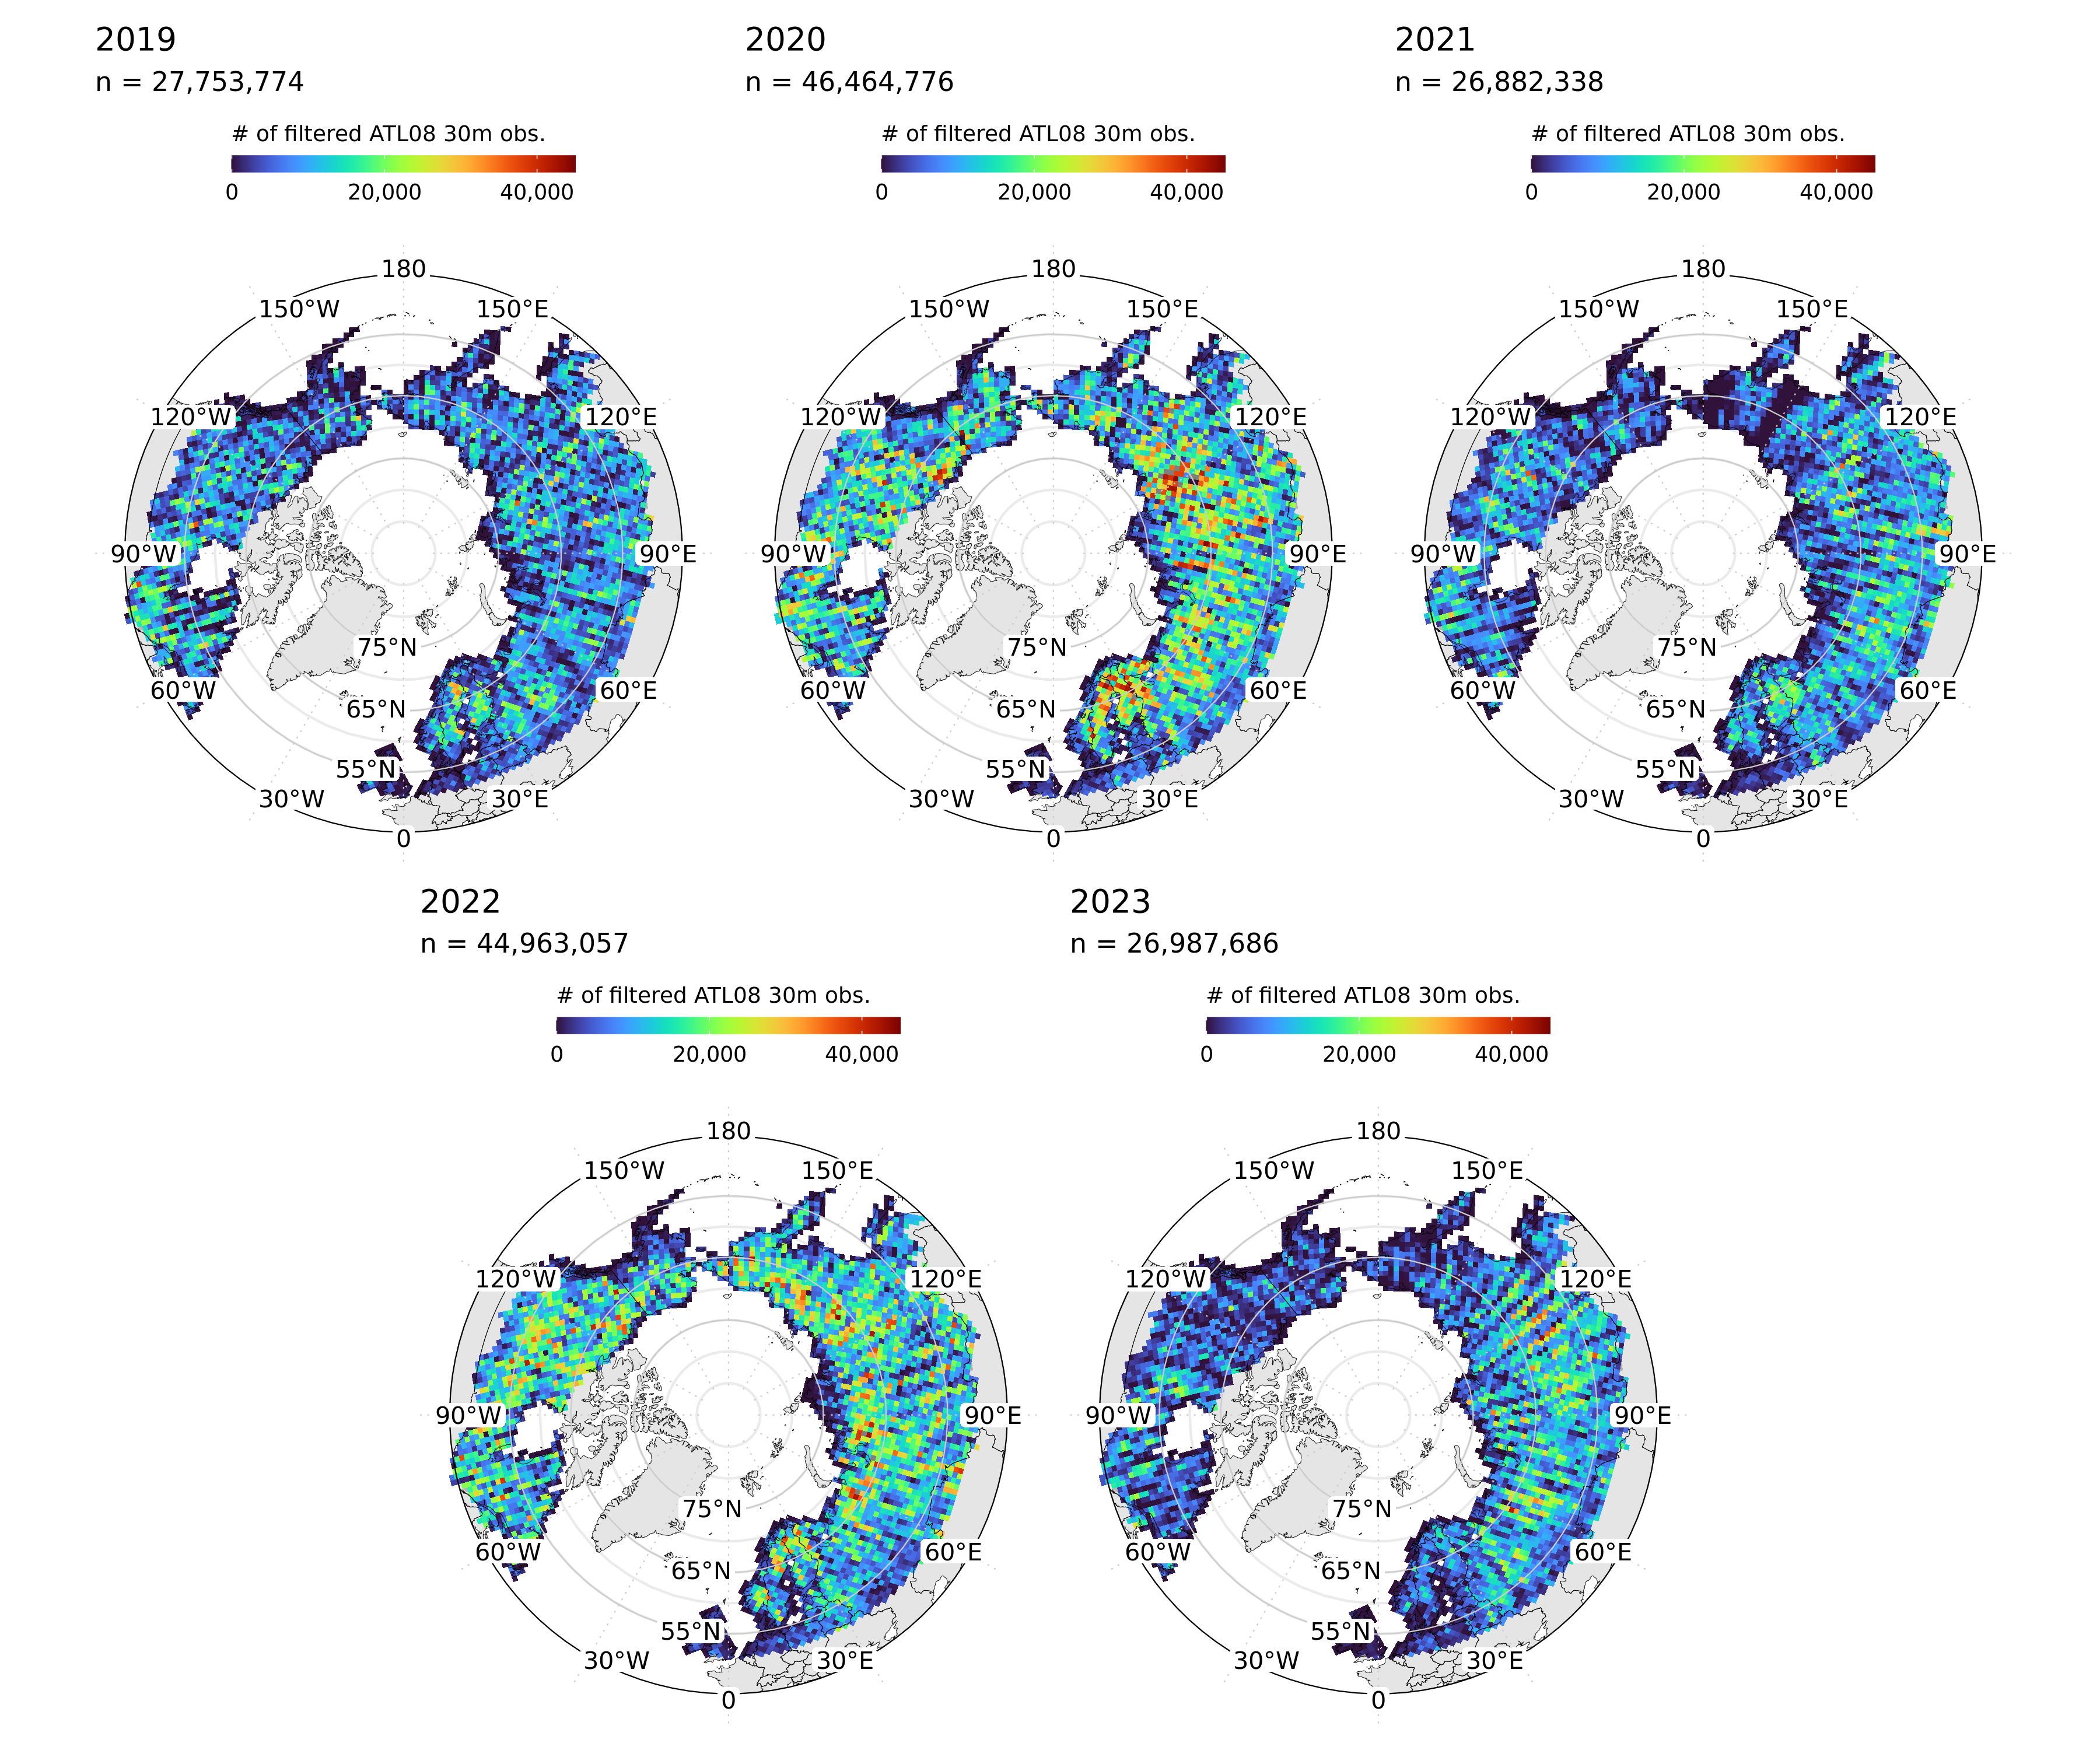

In [19]:
options(repr.plot.width = 12, repr.plot.height = 10, repr.plot.res = 300)

(
    (map_list[['n_obs.atl08v006_2019']] | map_list[['n_obs.atl08v006_2020']] | map_list[['n_obs.atl08v006_2021']] ) /
    (map_list[['n_obs.atl08v006_2022']] | map_list[['n_obs.atl08v006_2023']] ) 
    #+ plot_annotation(tag_levels = "a") 
 ) #+ plot_layout(guides = "collect")

In [120]:
z = read_csv('/projects/my-public-bucket/boreal_HLS_ATL08_metadata/data/HLS_params_all_years.csv')

New names:
• `` -> `...1`
Rows: 47041 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (5): start_month_day, end_month_day, json_path, run_type, temporal_window
dbl (7): ...1, Unnamed: 0, tile_num, max_cloud, start_year, end_year, num_sc...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [125]:
z[which(z$tile_num == 100),]

...1,Unnamed: 0,tile_num,max_cloud,start_month_day,end_month_day,start_year,end_year,json_path,num_scenes,run_type,temporal_window
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>
3780,3780,100,90,07-01,08-31,2023,2023,s3://maap-ops-workspace/montesano/dps_output/do_HLS_stack_3-1-2/HLS_stack_2023_v1/HLS_H30_2023/mc90_07-01_08-31_2023_2023/2023/10/12/03/07/05/898341/output-2023-10-12T03:07:05.898341.context.json,145,90_07-01_08-31_2023_2023,61 days
545,545,100,25,07-01,08-31,2022,2022,s3://maap-ops-workspace/montesano/dps_output/do_HLS_stack_3-1-2/HLS_stack_2023_v1/HLS_H30_2022/2023/04/17/19/27/19/319660/output-2023-04-17T19:27:19.319660.context.json,59,25_07-01_08-31_2022_2022,61 days
628,628,100,25,07-01,08-31,2021,2021,s3://maap-ops-workspace/montesano/dps_output/do_HLS_stack_3-1-2/HLS_stack_2023_v1/HLS_H30_2021/mc25_07-01_08-31_2021_2021/2024/03/16/22/07/28/539730/output-2024-03-16T22:07:28.539730.context.json,19,25_07-01_08-31_2021_2021,61 days
686,686,100,25,07-01,08-31,2020,2020,s3://maap-ops-workspace/montesano/dps_output/do_HLS_stack_3-1-2/HLS_stack_2023_v1/HLS_H30_2020/2023/04/11/01/50/50/260879/output-2023-04-11T01:50:50.260879.context.json,20,25_07-01_08-31_2020_2020,61 days
4768,4768,100,90,07-01,08-31,2019,2019,s3://maap-ops-workspace/montesano/dps_output/do_HLS_stack_3-1-2/HLS_stack_2023_v1/HLS_H30_2019/mc90_07-01_08-31_2019_2019/2023/10/06/16/36/03/088834/output-2023-10-06T16:36:03.088834.context.json,102,90_07-01_08-31_2019_2019,61 days
4415,4415,100,90,07-01,08-31,2018,2018,s3://maap-ops-workspace/montesano/dps_output/do_HLS_stack_3-1-2/HLS_stack_2023_v1/HLS_H30_2018/mc90_07-01_08-31_2018_2018/2023/08/03/19/41/54/702093/output-2023-08-03T19:41:54.702093.context.json,101,90_07-01_08-31_2018_2018,61 days
4852,4852,100,90,07-01,08-31,2017,2017,s3://maap-ops-workspace/montesano/dps_output/do_HLS_stack_3-1-2/HLS_stack_2023_v1/HLS_H30_2017/mc90_07-01_08-31_2017_2017/2023/07/29/03/50/09/649654/output-2023-07-29T03:50:09.649654.context.json,82,90_07-01_08-31_2017_2017,61 days
4620,4620,100,90,07-01,08-31,2016,2016,s3://maap-ops-workspace/montesano/dps_output/do_HLS_stack_3-1-2/HLS_stack_2023_v1/HLS_H30_2016/mc90_07-01_08-31_2016_2016/2023/07/21/21/10/18/455784/output-2023-07-21T21:10:18.455784.context.json,57,90_07-01_08-31_2016_2016,61 days
4153,0,100,75,06-15,09-01,2014,2016,s3://maap-ops-workspace/nathanmthomas/dps_output/do_HLS_stack_3-1-2_ubuntu/HLS_stack_2022_v2/2022/11/03/19/10/23/108945/HLS_100_06-15_09-01_2014_2016.tif,72,75_06-15_09-01_2014_2016,78 days
